# Practice

## Task
Your data source would be Kenneth French’s website.
http://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html
You’ll use monthly data from 1987 to the latest. You’ll need Fama French’s 5 factors
Market-Rf, SMB, HML, RMW and CMA. Additionally you may include Momentum (12-1
month) which you’ll find on this website as well. Analysis in question – dependent
variables are 12 Fama French industry portfolios. Use value weighted data.
Things to do:
1. a. What are the FF factor betas for each of the industry portfolios? In regression, does
it help to use 5 or 6 (includes MOM) factors or was original 3 or 4 (includes MOM)
factors model adequate? Are these betas time varying?
b. What regression technique can one employ to find more stable beta? How do your
results change?
2. Which industry portfolios are closely related to each other (how many groups exist –
a fundamental analyst may say there are two groups - defensive and cyclical)? Does this
relationship/group composition change through time?
What technique/s can you use to show this – why did you choose your technique over
others?
3. Construct minimum variance portfolio with constraints of not more than 50%
allocation to each group that you found in no. 2. Compare it with equal weighted 12
industry portfolio. Do monthly rebalancing for both.
Note – Results should be in tables and/or charts. They don’t need to be pretty/tidy, don’t
waste time on that.

Note – Results should be in tables and/or charts. They don’t need to be pretty/tidy, don’t
waste time on that.

## Data Preparation 

In [1]:
from pathlib import Path

Path = Path("/Users/lunoel/Documents/Python/Practice/Data")

In [2]:
import pandas as pd

Data = (pd.read_csv(Path / "F-F_Research_Data_5_Factors_2x3.csv")
      .assign(Date = lambda x: pd.to_numeric(x["Date"]))
      .query("Date >= 198700")
      .merge(pd.read_csv(Path / "F-F_Momentum_Factor.csv")
            .assign(Date = lambda x: pd.to_numeric(x["Date"]))
            .query("Date >= 198700"), on = "Date", how = "left")
      .merge(pd.read_csv(Path / "12_Industry_Portfolios.csv")
            .assign(Date = lambda x: pd.to_numeric(x["Date"]))
            .query("Date >= 198700"), on = "Date", how = "left"))


In [3]:
Data.isna().sum()

Date      0
Mkt-RF    0
SMB       0
HML       0
RMW       0
CMA       0
RF        0
Mom       0
NoDur     0
Durbl     0
Manuf     0
Enrgy     0
Chems     0
BusEq     0
Telcm     0
Utils     0
Shops     0
Hlth      0
Money     0
Other     0
dtype: int64

In [4]:
print("Shape:", Data.shape)
print("Unique dates:", Data["Date"].nunique())
print("\nData types:")

Shape: (475, 20)
Unique dates: 475

Data types:


## Question 1.-a

### <span style = "color : blue"> What are the FF factor betas for each of the industry portfolios?</span>

In [5]:
Industry = ["NoDur", "Durbl", "Manuf", "Enrgy", "Chems", "BusEq", "Telcm", "Utils", "Shops", "Hlth", "Money", "Other"]

FF = Data.copy()

FF[Industry] = FF[Industry].sub(FF["RF"], axis = 0)

FF.head()

,Date,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Other
0,198701,12.44,-1.61,-3.18,0.17,-1.03,0.42,2.06,14.04,18.24,13.81,13.73,14.39,16.05,4.88,8.88,11.30,12.73,10.01,13.23
1,198702,4.37,3.36,-5.86,-0.79,-2.55,0.43,-2.23,5.18,3.16,4.38,-2.19,4.23,9.09,-0.40,-2.58,9.38,10.69,3.51,6.56
2,198703,1.63,0.32,1.66,1.30,4.17,0.47,1.66,0.67,3.96,2.23,11.36,4.44,2.23,0.92,-2.15,1.21,-0.32,-1.95,2.57
3,198704,-2.09,-1.58,-0.36,-0.52,1.16,0.44,0.21,-4.12,3.67,-2.46,-0.33,-0.92,3.99,-2.91,-4.77,-3.14,-2.89,-5.39,-1.86
4,198705,0.11,-0.58,0.22,0.49,1.13,0.38,-0.80,2.25,-1.67,-0.33,2.64,0.66,-0.12,2.91,-2.23,-0.43,0.87,-1.13,1.66


### <span style = "color : blue"> In regression, does it help to use 5 or 6 (includes MOM) factors or was original 3 or 4 (includes MOM) factors model adequate?</span>

Overall, the 5 & 6 factor models provide better explanatory power than the original 3 & 4 factor models for most industry portfolios. The improvement is particularly evident for NoDur, Chems, Shops, BusEq, Utils, Hlth, Money, and Other. Durbl is the clearest exception, where FF4 appears adequate, while Enrgy shows only limited improvement from adding RMW and CMA.

This conclusion is supported by four model comparison measures:

- **Adjusted R²:** For most industries, FF5 or FF6 has the highest adjusted R², indicating that the additional factors improve explanatory power even after adjusting for model complexity. The improvement is especially large for NoDur, Chems, and Shops.

- **AIC:** FF5 or FF6 has the lowest AIC for 11 of the 12 industries, suggesting that the additional factors generally improve model fit enough to justify the added complexity. Durbl is the exception, where FF4 has the lowest AIC.

- **BIC:** FF5 or FF6 also has the lowest BIC for most industries, although BIC penalizes additional parameters more heavily. Durbl favors FF4 and Enrgy favors FF3 under BIC, suggesting that the simpler models may be adequate for these industries.

- **Joint F-test:** The null hypothesis that the RMW and CMA coefficients are jointly equal to zero is rejected for 11 of the 12 industries in both the FF3-vs-FF5 and FF4-vs-FF6 comparisons. This indicates that RMW and CMA provide statistically significant incremental explanatory power for most industries. Durbl is the only clear exception, with p-values of 0.216 and 0.393, so the null hypothesis cannot be rejected.

Therefore, the evidence generally favors FF5/FF6 over FF3/FF4. However, the benefit of the additional factors is industry-dependent rather than universal, with Durbl adequately explained by FF4 and Enrgy showing only modest incremental improvement.

In [6]:
import statsmodels.api as sm

Factor5 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

FF5 = []

for ix in Industry:
      
    # Run OLS regression
    model = sm.OLS(FF[ix], sm.add_constant(FF[Factor5])).fit()
    
    # Store results
    FF5.append({
        "Industry": ix,
        "Alpha": model.params["const"],
        "Mkt-RF": model.params["Mkt-RF"],
        "SMB": model.params["SMB"],
        "HML": model.params["HML"],
        "RMW": model.params["RMW"],
        "CMA": model.params["CMA"],
        "R^2": model.rsquared,
        "Adj R^2": model.rsquared_adj,
        "F-test-P-value": model.f_pvalue
    })

pd.DataFrame(FF5)


,Industry,Alpha,Mkt-RF,SMB,HML,RMW,CMA,R^2,Adj R^2,F-test-P-value
0,NoDur,-0.151901,0.812371,0.003630,-0.065525,0.533276,0.426704,0.695899,0.692657,9.287339e-119
1,Durbl,-0.211033,1.338435,0.323547,0.294814,0.125904,-0.231631,0.548886,0.544077,9.476727e-79
2,Manuf,-0.104145,1.162750,0.211189,0.181229,0.185162,0.121034,0.843028,0.841354,5.557923e-186
3,Enrgy,-0.137519,0.931599,0.175587,0.532552,0.221707,0.337763,0.458075,0.452298,3.454376e-60
4,Chems,-0.302722,0.936147,0.035354,-0.027207,0.480585,0.417593,0.731351,0.728487,2.377816e-131
5,BusEq,0.397909,1.147208,0.011172,-0.412482,-0.350920,-0.337927,0.855154,0.853610,3.683289e-194
6,Telcm,-0.223268,0.935539,-0.210206,0.016394,-0.086850,0.303828,0.606006,0.601806,1.789834e-92
7,Utils,0.028495,0.561370,-0.140269,0.113235,0.181327,0.431103,0.349998,0.343068,7.669367e-42
8,Shops,-0.025543,0.973440,0.164697,-0.103342,0.469105,-0.083033,0.792913,0.790705,8.362799e-158
9,Hlth,0.115555,0.803282,-0.080078,-0.308702,0.172794,0.419392,0.557206,0.552485,1.231912e-80


In [7]:
Factor3 = ["Mkt-RF", "SMB", "HML"]
Factor4 = ["Mkt-RF", "SMB", "HML", "Mom"]
Factor6 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]

ModelCompare = []

for ix in Industry:

    y = FF[ix]

    FF3 = sm.OLS(y, sm.add_constant(FF[Factor3])).fit()
    FF4 = sm.OLS(y, sm.add_constant(FF[Factor4])).fit()
    FF5 = sm.OLS(y, sm.add_constant(FF[Factor5])).fit()
    FF6 = sm.OLS(y, sm.add_constant(FF[Factor6])).fit()

    ModelCompare.append({
        "Industry": ix,
        "FF3 Adj R^2": FF3.rsquared_adj,
        "FF4 Adj R^2": FF4.rsquared_adj,
        "FF5 Adj R^2": FF5.rsquared_adj,
        "FF6 Adj R^2": FF6.rsquared_adj,
        "FF3 AIC": FF3.aic,
        "FF4 AIC": FF4.aic,
        "FF5 AIC": FF5.aic,
        "FF6 AIC": FF6.aic,
        "FF3 BIC": FF3.bic,
        "FF4 BIC": FF4.bic,
        "FF5 BIC": FF5.bic,
        "FF6 BIC": FF6.bic
    })

pd.DataFrame(ModelCompare)

,Industry,FF3 Adj R^2,FF4 Adj R^2,FF5 Adj R^2,FF6 Adj R^2,FF3 AIC,FF4 AIC,FF5 AIC,FF6 AIC,FF3 BIC,FF4 BIC,FF5 BIC,FF6 BIC
0,NoDur,0.586638,0.586915,0.692657,0.692095,2256.360411,2257.032587,2117.568808,2119.422711,2273.013670,2277.849161,2142.548697,2148.565914
1,Durbl,0.543038,0.566084,0.544077,0.565966,3009.197584,2985.607366,3010.095451,2987.711012,3025.850843,3006.423940,3035.075340,3016.854216
2,Manuf,0.835876,0.835766,0.841354,0.841447,2133.782745,2135.089769,2119.635996,2120.344157,2150.436004,2155.906343,2144.615885,2149.487361
3,Enrgy,0.442891,0.441708,0.452298,0.451302,2842.777041,2844.775270,2836.666752,2838.516206,2859.430300,2865.591844,2861.646641,2867.659409
4,Chems,0.657743,0.657249,0.728487,0.727941,2277.184498,2278.859931,2169.175706,2171.115727,2293.837757,2299.676505,2194.155595,2200.258930
5,BusEq,0.836055,0.840564,0.853610,0.856783,2309.439331,2297.184702,2257.623209,2248.199602,2326.092590,2318.001276,2282.603098,2277.342806
6,Telcm,0.593406,0.597923,0.601806,0.608455,2474.159392,2469.844018,2466.222375,2459.209686,2490.812651,2490.660592,2491.202264,2488.352890
7,Utils,0.310021,0.320523,0.343068,0.349244,2494.595976,2488.301004,2473.261315,2469.760687,2511.249235,2509.117578,2498.241204,2498.903891
8,Shops,0.745893,0.745606,0.790705,0.790456,2211.329402,2212.855120,2121.152060,2122.704157,2227.982661,2233.671694,2146.131949,2151.847360
9,Hlth,0.528178,0.532351,0.552485,0.554285,2431.592496,2428.363200,2408.447595,2407.519862,2448.245756,2449.179774,2433.427484,2436.663065


In [8]:
FTest = []

for ix in Industry:

    y = FF[ix]

    FF3 = sm.OLS(y, sm.add_constant(FF[Factor3])).fit()
    FF4 = sm.OLS(y, sm.add_constant(FF[Factor4])).fit()
    FF5 = sm.OLS(y, sm.add_constant(FF[Factor5])).fit()
    FF6 = sm.OLS(y, sm.add_constant(FF[Factor6])).fit()

    # FF3 vs FF5:
    # H0: beta_RMW = beta_CMA = 0
    F_3v5, p_3v5, df_3v5 = FF5.compare_f_test(FF3)

    # FF4 vs FF6:
    # H0: beta_RMW = beta_CMA = 0
    F_4v6, p_4v6, df_4v6 = FF6.compare_f_test(FF4)

    FTest.append({
        "Industry": ix,
        "FF3 vs FF5 p-value": p_3v5,
        "FF4 vs FF6 p-value": p_4v6
    })

pd.DataFrame(FTest)

,Industry,FF3 vs FF5 p-value,FF4 vs FF6 p-value
0,NoDur,2.425841e-31,5.046228e-31
1,Durbl,2.162167e-01,3.928986e-01
2,Manuf,1.286052e-04,9.759541e-05
3,Enrgy,6.796890e-03,6.384137e-03
4,Chems,9.656734e-25,1.237779e-24
5,BusEq,1.078405e-12,4.613042e-12
6,Telcm,2.758365e-03,7.396496e-04
7,Utils,3.699467e-06,1.505091e-05
8,Shops,6.426439e-21,7.188981e-21
9,Hlth,1.513616e-06,4.839918e-06


### <span style = "color : blue">  Are these betas time varying? </span>

To examine whether factor exposures change through time, I estimate **60-month rolling**<sup>1</sup> regressions using the **5 factors model**<sup>2</sup>.

Yes, the betas are time varying. The 60-month rolling regressions show that factor exposures change materially through time, although the degree of variation differs across factors and industries.

- **Market beta (Mkt-RF):** Market exposure is relatively more stable than the other factor betas. Most industries remain around a beta of approximately 1, although Durbl and Enrgy show noticeably larger variation. For example, Durbl's market beta ranges from 0.90 to 1.93, while Other is much more stable with a standard deviation of only 0.05.

- **Size beta (SMB):** SMB exposures vary through time and frequently change sign. The variation is particularly large for Durbl and Enrgy, with Durbl ranging from -0.07 to 1.37 and Enrgy from -0.57 to 0.81. This suggests that industry exposure to the size factor is not constant.

- **Value beta (HML):** HML shows substantial time variation across several industries. Durbl ranges from -0.93 to 1.58, Enrgy from -0.54 to 1.58, and Utils from -0.62 to 1.05. Several industries switch between positive and negative HML exposure over time.

- **Profitability beta (RMW):** RMW exposures are also highly time varying. Enrgy shows the largest variation, ranging from -1.27 to 1.85. Durbl, Hlth, NoDur, and Telcm also exhibit meaningful changes in both magnitude and sign.

- **Investment beta (CMA):** CMA is one of the most variable factor exposures. Enrgy ranges from -1.75 to 1.79, Durbl from -1.34 to 1.35, and Telcm from -0.64 to 1.26. The rolling estimates frequently cross zero, indicating changing investment-factor exposure.

Overall, market beta is comparatively stable, while SMB, HML, RMW, and CMA exposures vary substantially across time and, in many cases, change sign. Therefore, the full-sample OLS betas should be interpreted as long-run average factor exposures rather than constant sensitivities.

<sup>1</sup>**Why a 60-month rolling window?**  
A five-year window provides a balance between estimation stability and responsiveness. A shorter window would react more quickly to changing market conditions but could produce noisy beta estimates, while a much longer window would provide more stable estimates but could smooth over economically meaningful changes in factor exposures. Using 60 monthly observations therefore allows the regression to capture medium-term changes while retaining enough observations to estimate five factor betas.

<sup>2</sup>**Why 5 factors model?**  
The previous model comparison shows that 5 & 6 generally outperform 3 & 4 across most industries, and the joint F-tests indicate that RMW and CMA add significant explanatory power for 11 of the 12 industries. I therefore use 5 factors as the baseline model for the time-varying beta analysis. Momentum is excluded here to keep the analysis focused on the core Fama–French factors and to avoid adding unnecessary complexity when examining beta stability.



In [9]:
from statsmodels.regression.rolling import RollingOLS

RollingFF5 = []

for ix in Industry:

    RollingBeta = RollingOLS(FF[ix], sm.add_constant(FF[Factor5]), window = 60).fit()

    Tmp = (RollingBeta.params.copy() 
        .assign(Date = lambda x: FF["Date"].values)
        .assign(Industry = lambda x: ix))

    RollingFF5.append(Tmp)

RollingFF5 = pd.concat(RollingFF5, ignore_index = True)
RollingFF5 = RollingFF5.dropna()


(RollingFF5
.groupby("Industry")[Factor5]
.agg(["mean", "std", "min", "max"]))


Mkt-RF                                     SMB            \
              mean       std       min       max      mean       std   
Industry                                                               
BusEq     1.067780  0.155109  0.696329  1.465696  0.058464  0.242488   
Chems     0.960232  0.122576  0.722793  1.212986 -0.042340  0.122388   
Durbl     1.362429  0.251906  0.904821  1.929013  0.499579  0.306889   
Enrgy     1.024723  0.240276  0.575345  1.548484 -0.000428  0.322385   
Hlth      0.799997  0.165351  0.371039  1.070657 -0.150447  0.200676   
Manuf     1.170211  0.132778  0.966713  1.447950  0.251668  0.112155   
Money     1.091683  0.132695  0.838299  1.447220 -0.082584  0.166892   
NoDur     0.842299  0.148359  0.539185  1.235634 -0.071759  0.174584   
Other     1.049335  0.048836  0.796453  1.142288  0.156576  0.119967   
Shops     0.937088  0.107539  0.718101  1.174094  0.190437  0.171547   
Telcm     0.967450  0.140015  0.595698  1.437132 -0.188489  0.227105   
Utils     0.622556  0.137000  0.267106  0.951675 -0.181435  0.202767   

                                   HML                                \
               min       max      mean       std       min       max   
Industry                                                               
BusEq    -0.357452  0.510053 -0.317945  0.320764 -0.862981  0.499694   
Chems    -0.307627  0.302012 -0.041622  0.142056 -0.505005  0.345842   
Durbl    -0.070085  1.368457  0.300224  0.518005 -0.929667  1.583399   
Enrgy    -0.567490  0.805158  0.376513  0.520447 -0.542761  1.581185   
Hlth     -0.530125  0.275555 -0.526233  0.371992 -1.314616  0.091233   
Manuf     0.010632  0.516462  0.067880  0.126552 -0.196380  0.324508   
Money    -0.460294  0.251567  0.768389  0.165420  0.268819  1.217222   
NoDur    -0.461042  0.208109 -0.093059  0.216682 -0.503207  0.280670   
Other    -0.018624  0.473137  0.129310  0.117519 -0.265016  0.423808   
Shops    -0.189409  0.553094 -0.028720  0.262768 -0.497346  0.567870   
Telcm    -0.845286  0.184570 -0.057479  0.201122 -0.434234  0.438406   
Utils    -0.615785  0.256389  0.124134  0.420144 -0.619828  1.045246   

               RMW                                     CMA            \
              mean       std       min       max      mean       std   
Industry                                                               
BusEq    -0.161509  0.243165 -0.842903  0.359181 -0.527855  0.452949   
Chems     0.344457  0.202002 -0.114201  1.061381  0.330962  0.299589   
Durbl     0.140082  0.400671 -0.775237  1.077815  0.010602  0.539079   
Enrgy    -0.025731  0.656398 -1.274911  1.851305  0.198980  0.678276   
Hlth     -0.191985  0.317471 -0.768074  0.619972  0.421142  0.362820   
Manuf     0.266984  0.159924 -0.272116  0.735326  0.052044  0.209407   
Money    -0.272287  0.211703 -0.672338  0.174282 -0.354606  0.338230   
NoDur     0.464731  0.284057 -0.317646  1.105974  0.439817  0.204325   
Other     0.016100  0.147604 -0.307961  0.392406  0.014590  0.173711   
Shops     0.300918  0.154347 -0.106723  0.678531 -0.065008  0.332886   
Telcm     0.068600  0.281229 -0.918699  0.560010  0.449630  0.408666   
Utils     0.075547  0.314358 -0.586911  0.756603  0.336088  0.356553   

                              
               min       max  
Industry                      
BusEq    -1.485799  0.428322  
Chems    -0.380935  1.031324  
Durbl    -1.339457  1.351117  
Enrgy    -1.753715  1.791571  
Hlth     -0.280238  1.443890  
Manuf    -0.477040  0.533964  
Money    -1.230429  0.264423  
NoDur    -0.044806  1.038196  
Other    -0.373984  0.346202  
Shops    -0.724523  0.441163  
Telcm    -0.640420  1.262542  
Utils    -0.405782  1.339258

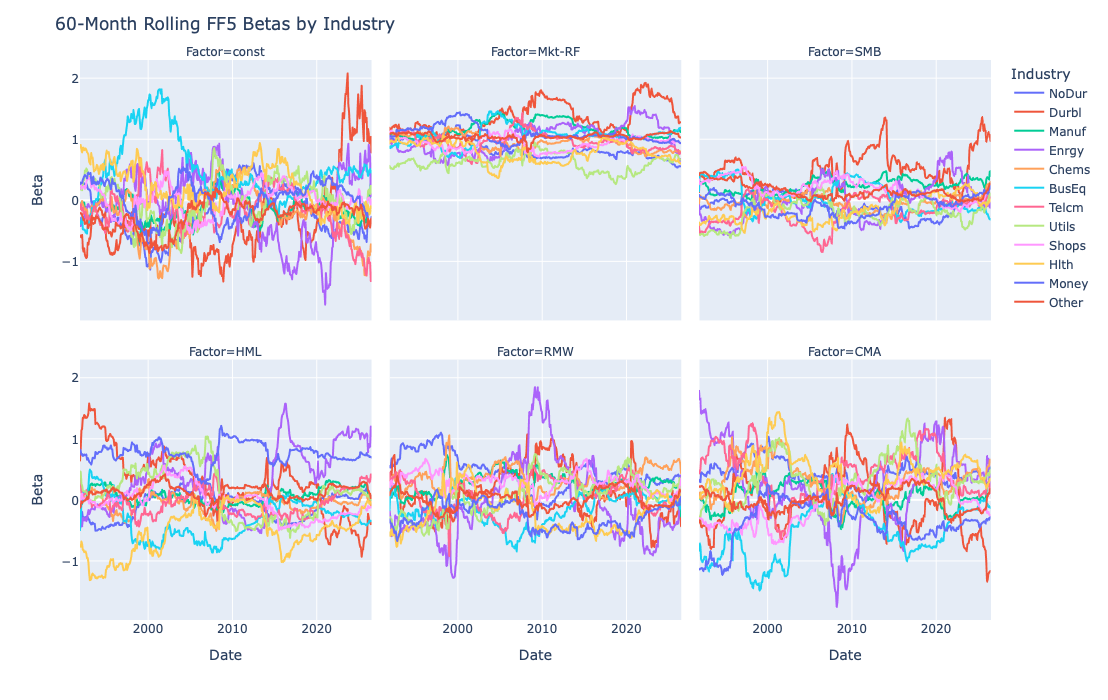

In [10]:
import plotly.express as px

Tmp = RollingFF5.copy()

Tmp["Date"] = pd.to_datetime(Tmp["Date"].astype(str), format = "%Y%m")


Tmp = (Tmp
    .melt(id_vars = ["Date", "Industry"],
          value_vars = ["const", "Mkt-RF", "SMB", "HML", "RMW", "CMA"],
          var_name = "Factor",
          value_name = "Beta"))

fig = px.line(Tmp, x = "Date", y = "Beta", color = "Industry", facet_col = "Factor", facet_col_wrap = 3)
fig.update_layout(height = 700, title = "60-Month Rolling FF5 Betas by Industry")
fig.show()

## Question 1.-b

### <span style = "color : blue">  What regression technique can one employ to find more stable beta? </span>

A penalized regression can be used to obtain more stable beta estimates. In particular, LASSO and Ridge regularization shrink regression coefficients toward zero by adding a penalty to the OLS objective function.

Compared with OLS, regularization can reduce the sensitivity of estimated betas to sampling noise and therefore reduce the variance of the beta estimates. The trade-off is a bias–variance trade-off: some bias is introduced in exchange for lower estimation variance and potentially more stable coefficients.

LASSO uses an **L1 penalty**<sup>1</sup> and may shrink some coefficients exactly to zero, resulting in a more parsimonious model. Ridge uses an **L2 penalty**<sup>2</sup> and generally retains all factors while shrinking their coefficients toward zero.

<sup>1</sup>LASSO：L1 penalty
$$
\lambda \sum_j |\beta_j|
$$
<sup>2</sup>Ridge：L2 penalty
$$
\lambda \sum_j \beta_j^2
$$

### <span style = "color : blue">  How do your results change? </span>

Regularization improves the stability of most non-market factor betas, but the effect is not uniform across factors.

LASSO produces the largest reduction in beta variability for SMB, HML, RMW, and CMA, reducing their rolling standard deviations by approximately 18%–21% relative to OLS. Ridge also improves stability for these factors, but the reductions are much smaller, at approximately 4%–7%.

However, neither method improves the stability of the market beta. The standard deviation of Mkt-RF beta increases by approximately 30% under LASSO and 16% under Ridge.

Overall, LASSO is more effective than Ridge at stabilizing the non-market factor exposures, but regularization does not universally produce more stable coefficients. In particular, the market beta becomes more variable under both penalized regressions.

- **Mkt-RF:** Beta variability increases by 30.3% under LASSO and 15.6% under Ridge. Therefore, regularization does not improve the stability of the market beta.

- **SMB:** LASSO reduces beta variability by 19.7%, compared with only 4.7% under Ridge.

- **HML:** LASSO reduces beta variability by 19.6%, while Ridge reduces it by 6.9%.

- **RMW:** LASSO reduces beta variability by 17.8%, compared with 3.9% under Ridge.

- **CMA:** LASSO provides the largest stabilization effect, reducing beta variability by 20.5%, while Ridge reduces it by 6.0%.

In [11]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import numpy as np
import pandas as pd

RollingPenalized = []

RollingN = 60
TuneN = 12

for ix in Industry:

    LassoAlpha = None
    RidgeAlpha = None

    for ii in range(RollingN, len(FF) + 1):

        Tmp = FF.iloc[ii - RollingN : ii]

        # Re-tune alpha every 12 months
        if (ii - RollingN) % TuneN == 0:

            # ----- LASSO -----
            lasso_pipe = Pipeline([("scaler", StandardScaler()), ("model", Lasso(max_iter = 10000))])

            lasso_grid = GridSearchCV(estimator=lasso_pipe, param_grid = {"model__alpha": np.logspace(-4, 1, 30)},
                cv = TimeSeriesSplit(n_splits = 3), scoring = "neg_mean_squared_error")

            lasso_grid.fit(Tmp[Factor5], Tmp[ix])

            LassoAlpha = lasso_grid.best_params_["model__alpha"]


            # ----- RIDGE -----
            ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])

            ridge_grid = GridSearchCV(estimator = ridge_pipe, param_grid = {"model__alpha": np.logspace(-4, 4, 30)},
                cv = TimeSeriesSplit(n_splits = 3), scoring = "neg_mean_squared_error")

            ridge_grid.fit(Tmp[Factor5], Tmp[ix])

            RidgeAlpha = ridge_grid.best_params_["model__alpha"]

        # Use the selected alpha for rolling estimation
        scaler = StandardScaler()
        
        LassoModel = Lasso(alpha = LassoAlpha, max_iter = 10000
        ).fit(scaler.fit_transform(Tmp[Factor5]), Tmp[ix])

        RidgeModel = Ridge(alpha = RidgeAlpha
        ).fit(scaler.fit_transform(Tmp[Factor5]), Tmp[ix])

        # Convert coefficients back to original scale
        LassoBeta = LassoModel.coef_ / scaler.scale_
        RidgeBeta = RidgeModel.coef_ / scaler.scale_

        RollingPenalized.append({
            "Date": FF.iloc[ii - 1]["Date"],
            "Industry": ix,
            "Lasso_Mkt-RF": LassoBeta[0],
            "Lasso_SMB": LassoBeta[1],
            "Lasso_HML": LassoBeta[2],
            "Lasso_RMW": LassoBeta[3],
            "Lasso_CMA": LassoBeta[4],
            "Ridge_Mkt-RF": RidgeBeta[0],
            "Ridge_SMB": RidgeBeta[1],
            "Ridge_HML": RidgeBeta[2],
            "Ridge_RMW": RidgeBeta[3],
            "Ridge_CMA": RidgeBeta[4],
            "Lasso_alpha": LassoAlpha,
            "Ridge_alpha": RidgeAlpha})

RollingPenalized = pd.DataFrame(RollingPenalized)

RollingPenalized.head()

,Date,Industry,Lasso_Mkt-RF,Lasso_SMB,Lasso_HML,Lasso_RMW,Lasso_CMA,Ridge_Mkt-RF,Ridge_SMB,Ridge_HML,Ridge_RMW,Ridge_CMA,Lasso_alpha,Ridge_alpha
0,199112.0,NoDur,1.017286,-0.096281,-0.196718,0.556296,0.326909,1.017317,-0.096305,-0.196842,0.556390,0.327137,0.0001,0.0001
1,199201.0,NoDur,1.010260,-0.135626,-0.221386,0.532768,0.297015,1.010296,-0.135650,-0.221515,0.532857,0.297256,0.0001,0.0001
2,199202.0,NoDur,1.014854,-0.140356,-0.181676,0.564648,0.296270,1.014892,-0.140378,-0.181794,0.564744,0.296509,0.0001,0.0001
3,199203.0,NoDur,1.034080,-0.118130,-0.194204,0.683240,0.456095,1.034123,-0.118149,-0.194323,0.683363,0.456373,0.0001,0.0001
4,199204.0,NoDur,1.012278,-0.097828,-0.282893,0.588554,0.450872,1.012311,-0.097867,-0.282884,0.588575,0.450973,0.0001,0.0001


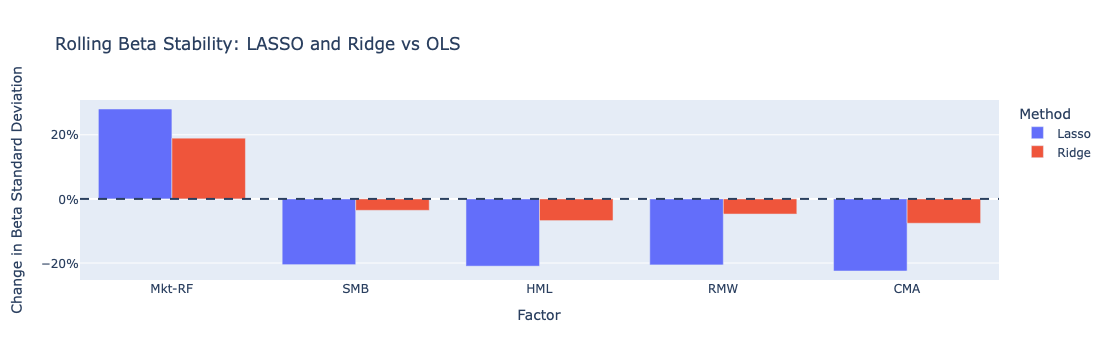

In [12]:
OLS_std = (RollingFF5
    .groupby("Industry")[Factor5]
    .std())

Lasso_std = (RollingPenalized
    .groupby("Industry")[
        ["Lasso_Mkt-RF", "Lasso_SMB", "Lasso_HML", "Lasso_RMW", "Lasso_CMA"]
    ].std())

Ridge_std = (
    RollingPenalized
    .groupby("Industry")[
        ["Ridge_Mkt-RF", "Ridge_SMB", "Ridge_HML", "Ridge_RMW", "Ridge_CMA"]
    ].std())

Lasso_std.columns = Factor5
Ridge_std.columns = Factor5

# Compare std reduce percent
Lasso_Change = Lasso_std / OLS_std - 1
Ridge_Change = Ridge_std / OLS_std - 1

StabilitySummary = (pd.DataFrame({"Lasso": Lasso_Change.mean(),
                                  "Ridge": Ridge_Change.mean()})
    .reset_index()
    .rename(columns={"index": "Factor"}))

Plot = (StabilitySummary
    .melt(id_vars = "Factor",
          var_name = "Method",
          value_name = "Std_Change"))

fig = px.bar(Plot, x = "Factor", y = "Std_Change", color = "Method", barmode = "group",
    title = "Rolling Beta Stability: LASSO and Ridge vs OLS")

fig.update_yaxes(tickformat = ".0%", title = "Change in Beta Standard Deviation")
fig.update_xaxes(title = "Factor")
fig.add_hline(y = 0, line_dash="dash")
fig.show()


## Question 2

### <span style = "color : blue"> Which industry portfolios are closely related to each other?</span>

The correlation matrix shows substantial co-movement across the 12 industry portfolios, but the strength of the relationships differs meaningfully across industries.

The strongest pairwise relationships are observed between Manuf and Other (0.90), BusEq and Other (0.86), Shops and Other (0.83), Money and Other (0.83), and Manuf and Chems (0.82). More broadly, Manuf, Chems, BusEq, Shops, Money, and Other form a highly correlated group.

In contrast, Utils, Enrgy, Hlth, and Durbl generally exhibit weaker correlations with the rest of the industries. For example, Utils has relatively low correlations with Durbl (0.29), Shops (0.37), and Hlth (0.43).

Overall, the correlation structure suggests that some industries share strong common return co-movement, while others behave more distinctly. However, pairwise correlations alone do not determine the optimal number of groups, so clustering analysis is required in the next step.

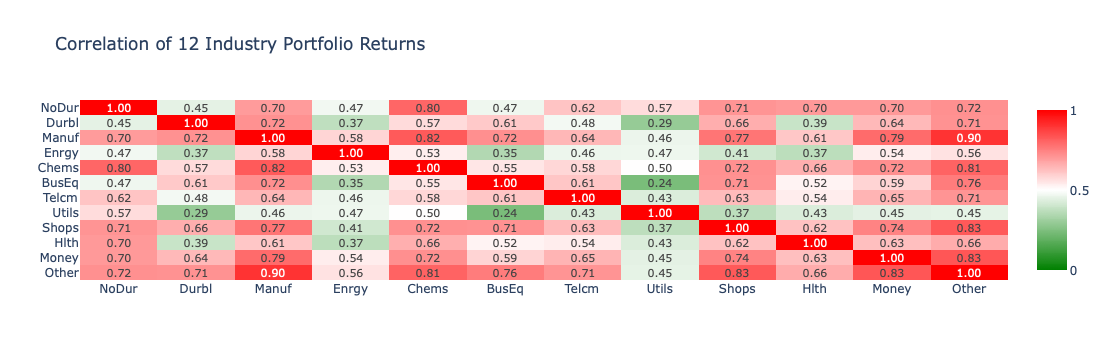

In [13]:
Cluster = Data.copy()

Corr = Cluster[Industry].corr()

fig = px.imshow(Corr, text_auto = ".2f", aspect = "auto", zmin = 0, zmax = 1,
    color_continuous_scale = [
        [0.0, "green"],
        [0.5, "white"],
        [1.0, "red"]],
    title = "Correlation of 12 Industry Portfolio Returns")
fig.show()

### <span style = "color : blue"> How many groups exist (a fundamental analyst may say there are two groups - defensive and cyclical? What techniques can you use to show this – why did you choose your technique over others?</span>

The empirical results support a **two-cluster structure** among the 12 industry portfolios. This is consistent with the idea that industries may broadly form two groups, although the data-driven clusters should not automatically be interpreted as the conventional “defensive” and “cyclical” classifications.

Among the cluster solutions tested from two to six groups, the **two-cluster solution has the highest silhouette score of 0.339**, compared with 0.295 for three clusters and substantially lower scores for four or more clusters. The dendrogram also shows a natural separation into two broad groups. However, the moderate silhouette score suggests that the separation is meaningful but not especially strong.

### Why hierarchical clustering?

This is an **unsupervised learning** problem because there is no predefined target variable or industry-group label. The objective is to identify groups of industries with similar return co-movement rather than to predict a target variable or reduce the number of features.

Hierarchical clustering is selected as the primary technique because the number of groups is not known in advance. Unlike K-means, which requires the number of clusters to be specified beforehand, hierarchical clustering allows the structure of the data to be examined at different levels through a dendrogram. PCA is not selected because it is primarily a dimension-reduction technique rather than a clustering method.

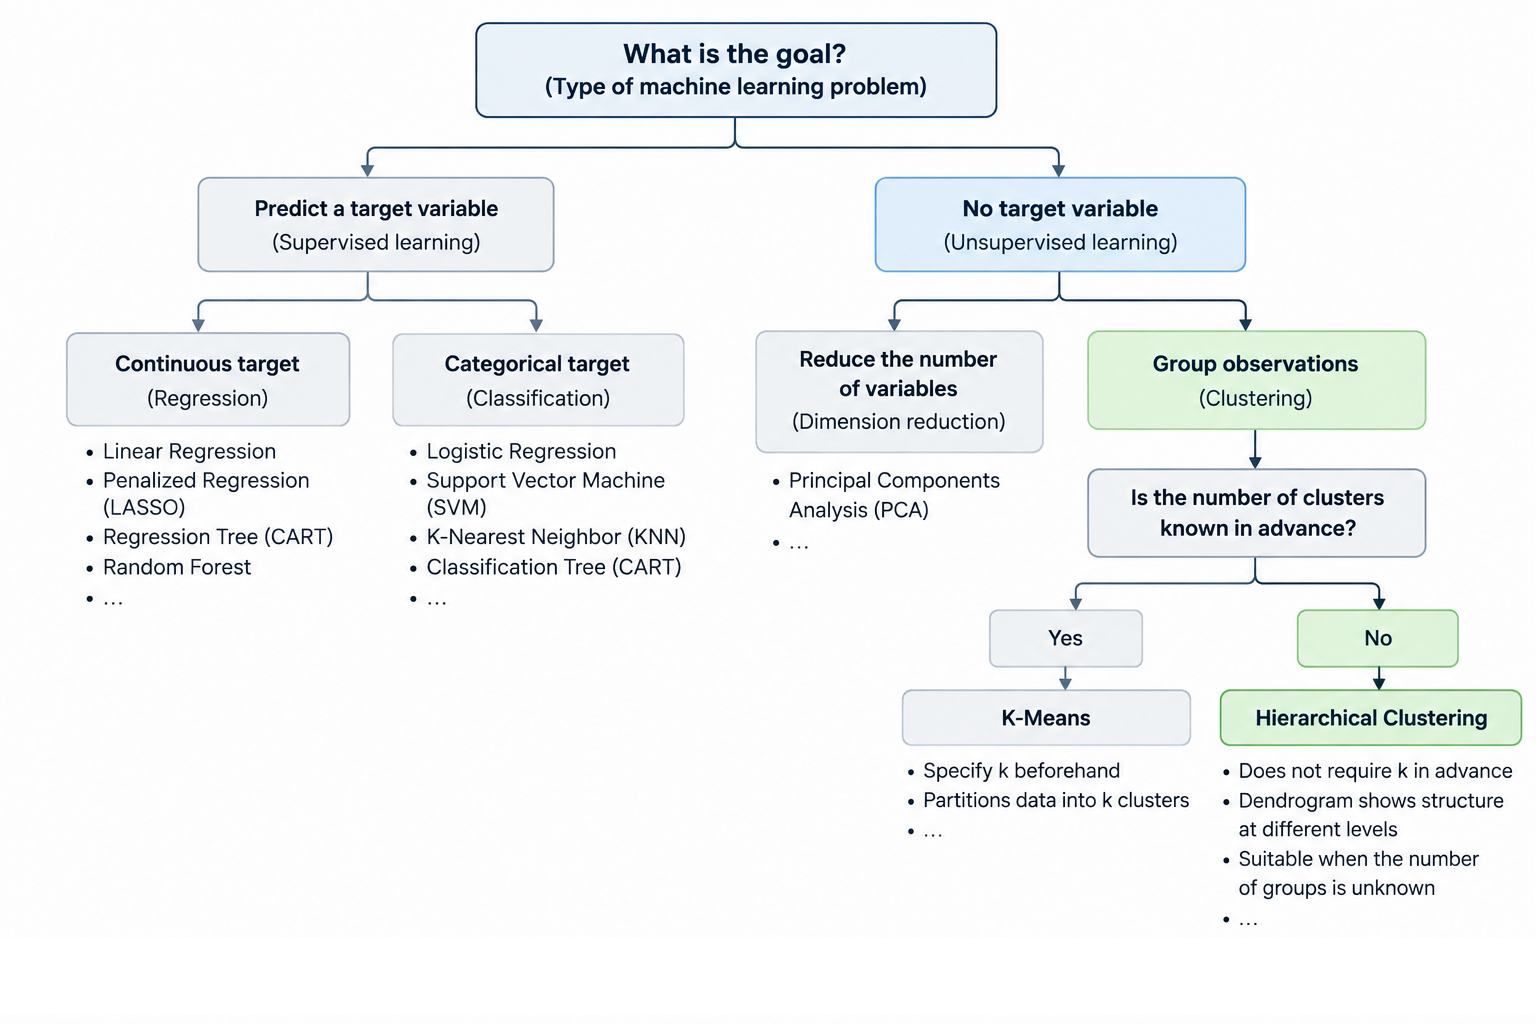
<span style = "color : gray"> **Source framework adapted from CFA® Program Curriculum 2026 Level II, Quantitative Methods, Learning Module 6 Machine Learning*</span>


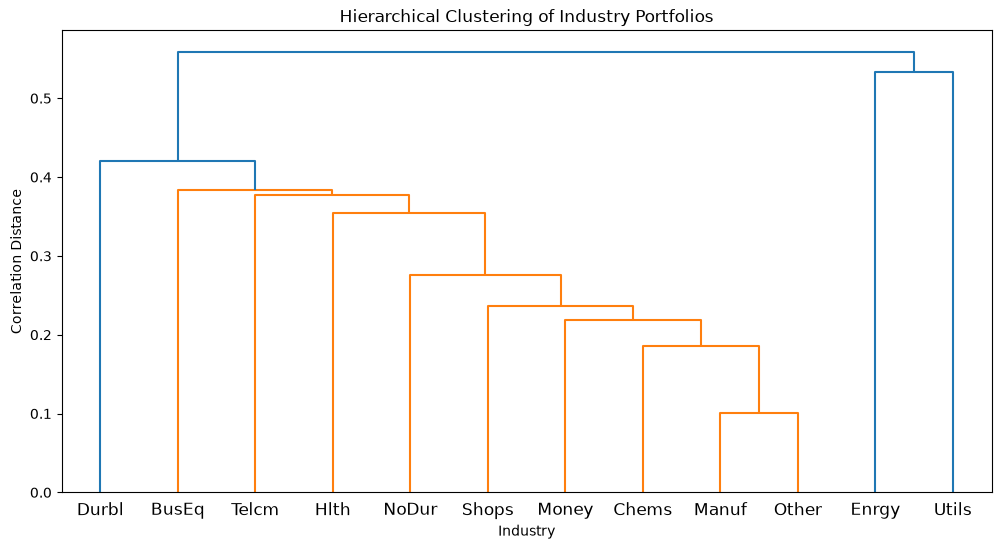

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

Distance = 1 - Corr

Distance_condensed = squareform(Distance, checks = False)

Z = linkage(Distance_condensed, method = "average")

plt.figure(figsize = (12, 6))

dendrogram(Z, labels = Industry)

plt.title("Hierarchical Clustering of Industry Portfolios")
plt.ylabel("Correlation Distance")
plt.xlabel("Industry")
plt.show()


In [15]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

Silhouette = []

for ix in range(2, 7):

    Labels = fcluster(Z, t = ix, criterion = "maxclust")

    Score = silhouette_score(Distance, Labels, metric = "precomputed")

    Silhouette.append({
        "Clusters": ix, 
        "Silhouette Score": Score})

pd.DataFrame(Silhouette)

,Clusters,Silhouette Score
0,2,0.339393
1,3,0.294563
2,4,0.155744
3,5,0.114483
4,6,0.127993


### <span style = "color : blue"> Does this relationship/group composition change through time?</span>


Yes. The relationship and group composition of the industry portfolios change through time, although a two-cluster structure remains the most persistent overall pattern.

This conclusion is supported by two rolling analyses:

- **Rolling cluster structure:** Using a five-year rolling window and re-estimating the clustering annually, the two-cluster solution has the highest silhouette score in most periods. However, the silhouette score varies substantially over time, and three- or four-cluster solutions become competitive in some periods. This indicates that the strength and structure of industry relationships are not constant.

- **Rolling group composition:** Even when the analysis is restricted to two clusters, individual industries move between groups over time. Some industries remain relatively stable, while others switch clusters during particular periods, indicating that the composition of the two broad groups also evolves.

Overall, the results suggest that **two clusters provide a useful long-run representation, but neither the strength of the clustering nor the membership of the groups is static through time.**

**Note:**

Cluster labels are arbitrary across rolling windows. To make membership comparable through time, cluster labels are aligned using **'Utils'**
as an anchor: the cluster containing Utils is consistently labeled as Cluster 2, and the other cluster as Cluster 1. This prevents numerical label switching from being mistaken for a genuine change in group composition.


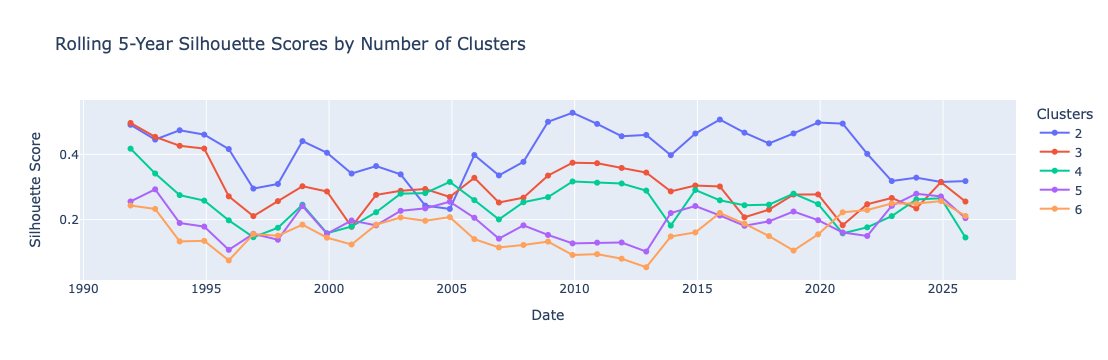

In [16]:
RollingSilhouette = []
RollingCluster = []

RollingN = 60
StepN = 12

for ix in range(RollingN, len(Cluster) + 1, StepN):

    Tmp = Cluster.iloc[ix - RollingN : ix]

    # Correlation-based distance
    Corr_tmp = Tmp[Industry].corr()
    Distance_tmp = 1 - Corr_tmp

    Distance_condensed = squareform(Distance_tmp, checks = False)

    # Hierarchical clustering
    Z_tmp = linkage(Distance_condensed, method = "average")

    # Compare number of clusters
    for ii in range(2, 7):

        Labels = fcluster(Z_tmp, t = ii, criterion = "maxclust")

        Score = silhouette_score(Distance_tmp, Labels, metric = "precomputed")

        RollingSilhouette.append({
            "Date": Cluster["Date"].iloc[ix - 1],
            "Clusters": ii, 
            "Silhouette Score": Score})

    # Keep two-cluster composition for comparison through time
    Labels2 = fcluster(Z_tmp, t = 2, criterion = "maxclust")

    for industry, label in zip(Industry, Labels2):

        RollingCluster.append({
            "Date": Cluster["Date"].iloc[ix - 1],
            "Industry": industry, 
            "Cluster": label})


RollingSilhouette = pd.DataFrame(RollingSilhouette)
RollingCluster = pd.DataFrame(RollingCluster)

RollingSilhouette["Date"] = pd.to_datetime(RollingSilhouette["Date"].astype(str), format = "%Y%m")

fig = px.line(RollingSilhouette, x = "Date", y = "Silhouette Score", color = "Clusters", markers = True, 
              title = "Rolling 5-Year Silhouette Scores by Number of Clusters")

fig.update_layout(xaxis_title = "Date", yaxis_title = "Silhouette Score")
fig.show()

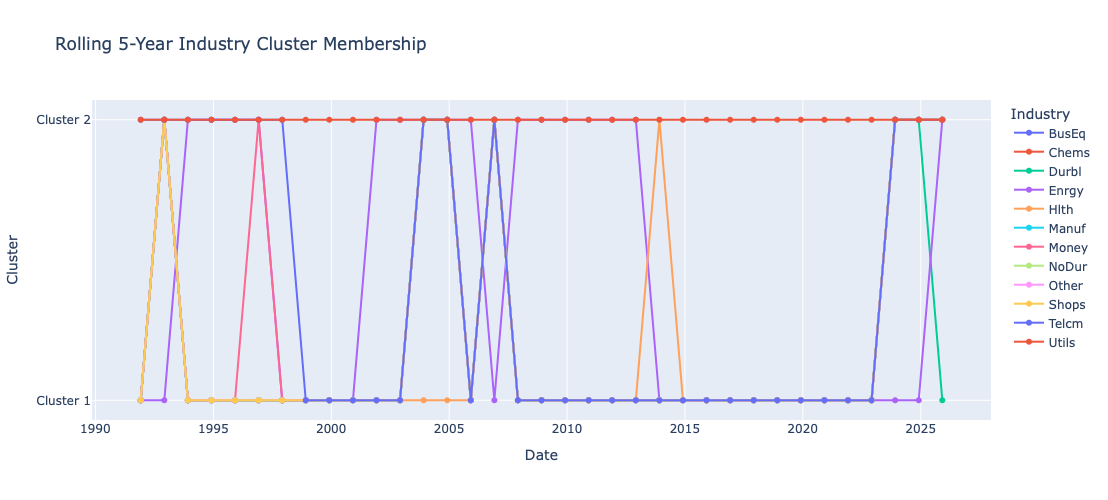

In [17]:
RollingCluster["Date"] = pd.to_datetime(RollingCluster["Date"].astype(int).astype(str), format = "%Y%m")

# fig = px.line(RollingCluster, x = "Date", y = "Cluster", color = "Industry", markers = True,
#     title="Rolling 5-Year Industry Cluster Membership")

# fig.update_layout(height = 450, xaxis_title = "Date", yaxis_title = "Cluster")
# fig.update_yaxes(tickmode = "array", tickvals = [1, 2], ticktext = ["Cluster 1", "Cluster 2"])
# fig.show()

RollingCluster = (
    RollingCluster
    
    # Find the cluster containing Utils in each year
    .merge(RollingCluster
        .query("Industry == 'Utils'")
        [["Date", "Cluster"]]
        .rename(columns = {"Cluster": "UtilsCluster"}), on = "Date", how = "left")
    
    # Always call the cluster containing Utils "Cluster 2"
    .assign(ClusterAligned = lambda x: np.where(x["Cluster"] == x["UtilsCluster"], 2, 1))
    .sort_values(["Industry", "Date"])
    .assign(LastCluster = lambda x: x.groupby("Industry")["ClusterAligned"].shift(1))
    .assign(Changed = lambda x: (x["ClusterAligned"] != x["LastCluster"]) & x["LastCluster"].notna()))

fig = px.line(RollingCluster, x = "Date", y = "ClusterAligned", color = "Industry", markers = True,
              title="Rolling 5-Year Industry Cluster Membership")

fig.update_layout(height = 500, xaxis_title = "Date", yaxis_title = "Cluster")
fig.update_yaxes(tickmode = "array", tickvals = [1, 2], ticktext = ["Cluster 1", "Cluster 2"])
fig.show()

## Question 3

### <span style = "color : blue"> Construct minimum variance portfolio with constraints of not more than 50% allocation to each group that you found in no. 2. Compare it with equal weighted 12 industry portfolio. Do monthly rebalancing for both. </span>


A minimum variance portfolio is constructed using a rolling 60-month covariance matrix and rebalanced monthly. Portfolio weights are constrained to be long-only and fully invested, with no more than 50% allocated to each of the two industry groups identified in Question 2.

Since the portfolio contains only two groups and each group is constrained to a maximum weight of 50%, the constraint effectively requires a 50% allocation to each group. The optimization therefore determines the minimum-variance allocation among industries within each group.

The optimized weights estimated using information available through month \(t\) are applied to returns in month \(t+1\), avoiding look-ahead bias. The benchmark is an equally weighted portfolio of the 12 industries, also rebalanced monthly.

| Portfolio | Annualized Return | Annualized Volatility |
|---|---:|---:|
| Equal Weight | 10.95% | 14.30% |
| Minimum Variance | 9.08% | 12.25% |

The minimum variance portfolio achieves its intended objective: its annualized volatility declines from **14.30% to 12.25%**, a reduction of approximately **2.05 percentage points** relative to the equal-weighted portfolio.

However, this reduction in risk comes with lower performance. The minimum variance portfolio generates an annualized return of **9.08%**, compared with **10.95%** for the equal-weighted portfolio. The cumulative performance chart also shows that the equal-weighted portfolio substantially outperforms over the full sample, with the performance gap becoming particularly pronounced in the later part of the sample.

Overall, the group-constrained minimum variance strategy provides a lower-risk but lower-return portfolio. The optimization successfully reduces portfolio volatility, but the lower-volatility allocation sacrifices some upside participation relative to a simple equally weighted portfolio.

In [18]:
# %pip install PyPortfolioOpt
from pypfopt import EfficientFrontier

def Optim(MatR, Group):

    Cov = MatR[Industry].cov()

    ef = EfficientFrontier(expected_returns = None, cov_matrix = Cov, weight_bounds=(0, 1))

    ef.add_sector_constraints(sector_mapper = Group, sector_lower = {1: 0, 2: 0}, sector_upper={1: 0.5, 2: 0.5})

    Weight = ef.min_volatility()

    return Weight


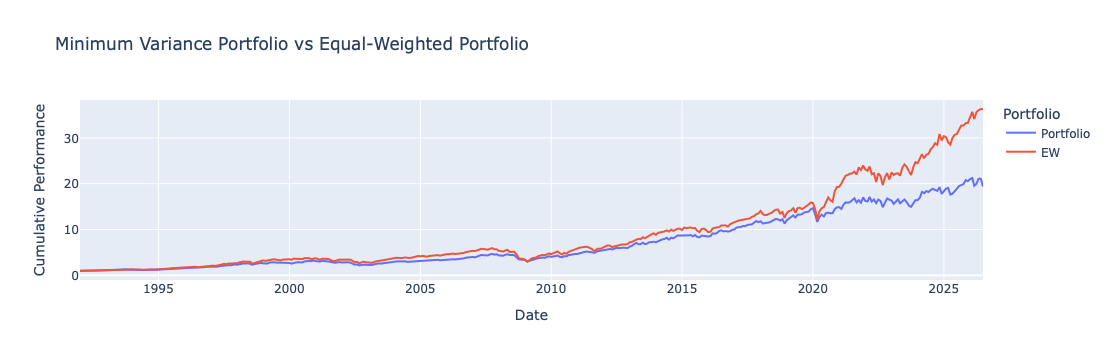

In [19]:
BT = (Data[["Date"] + Industry].copy()
    .assign(Date = lambda x: pd.to_datetime(x["Date"].astype(str), format = "%Y%m")))

BT[Industry] /= 100

GroupMonthly = (RollingCluster
    [["Date", "Industry", "ClusterAligned"]]
    .pivot(index = "Date", columns = "Industry", values = "ClusterAligned")
    .reindex(columns = Industry)
    .reset_index())

GroupMonthly = (BT[["Date"]]
    .merge(GroupMonthly, on = "Date", how = "left")
    .sort_values("Date")
    .ffill())


RollingN = 60

Weight = []

for ix in range(RollingN, len(BT)):

    # Previous 60 months
    MatR = BT.iloc[ix - RollingN:ix]
    
    RBLDate = BT["Date"].iloc[ix - 1]

    Group = (GroupMonthly
        .query("Date == @RBLDate")
        [Industry]
        .iloc[0]
        .to_dict())

    if pd.isna(list(Group.values())).any():
        continue

    # Optimization
    W = Optim(MatR = MatR, Group = Group)

    # Weight is used for next month's return
    Tmp = (pd.DataFrame({"Industry": W.keys(),
                         "Weight": W.values()})
        .assign(Date = BT["Date"].iloc[ix])
        [["Date", "Industry", "Weight"]])

    Weight.append(Tmp)

Weight = pd.concat(Weight, ignore_index = True)
 # (Weight.groupby("Date").agg(W = ("Weight", "sum")))

Backtest = (BT
    .melt(id_vars = "Date",
          value_vars = Industry,
          var_name = "Industry",
          value_name = "Ret"))

Backtest = (Backtest
    .merge(Weight, on = ["Date", "Industry"], how = "inner")
    .assign(WeightedRet = lambda x: x["Ret"] * x["Weight"])
    .groupby("Date", as_index = False)
    .agg(Ret = ("WeightedRet", "sum"))
    .sort_values("Date")
    .assign(Portfolio = lambda x: (1 + x["Ret"]).cumprod()))

Backtest = (BT[BT["Date"].isin(Backtest["Date"])]
    .assign(EWRet = lambda x: x[Industry].mean(axis = 1))
    .assign(EW = lambda x: (1 + x["EWRet"]).cumprod())
    [["Date", "EWRet", "EW"]]
    .merge(Backtest, on = "Date", how = "left"))

Plot = (Backtest[["Date", "Portfolio", "EW"]]
    .melt(id_vars = "Date",
          var_name = "Portfolio",
          value_name = "CumRet"))

fig = px.line(Plot, x = "Date", y = "CumRet", color = "Portfolio",
    title = "Minimum Variance Portfolio vs Equal-Weighted Portfolio")

fig.update_layout(xaxis_title = "Date", yaxis_title = "Cumulative Performance")
fig.show()

In [20]:
(Plot
    .sort_values(["Portfolio", "Date"])
    .assign(Ret = lambda x: x.groupby("Portfolio")["CumRet"].pct_change())
    .dropna(subset = ["Ret"])
    .groupby("Portfolio")
    .agg(AnnualReturn = ("Ret", lambda x: (1 + x).prod() ** (12 / len(x)) - 1),
         AnnualVol = ("Ret", lambda x: x.std() * np.sqrt(12)))
    .reset_index())

,Portfolio,AnnualReturn,AnnualVol
0,EW,0.109467,0.143040
1,Portfolio,0.090838,0.122473
